In [ ]:
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
import pandas as pd

import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import VotingRegressor
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [152]:
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "AppleGothic")
# 음수 표시
matplotlib.rc("axes", unicode_minus = False)

In [153]:
df = pd.read_csv("df_merged.csv", encoding="cp949")
df.head()

,idUser,idOrder,OrderDT,ItemCode,Price,DeliveryDT,OrderYear,OrderMonth,OrderDay,OrderHour,...,ItemSmallCode,ItemSmallName,ItemName,PriceMin,PriceMax,Gender,Age,FamilyCount,MemberYN,AgeGroup
0,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M17-S0530-1024,33310,2023-01-07 06:24:00,2023,1,6,17,...,S0530,전복,완도 활전복 1kg 중 22-25미,33160.0,37070.0,여성,26,2,Y,20
1,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M21-S0540-1082,3780,2023-01-07 06:24:00,2023,1,6,17,...,S0540,즉석,동원 양반 차돌된장찌개 (460G),3690.0,3970.0,여성,26,2,Y,20
2,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M15-S0140-1311,22520,2023-01-07 06:24:00,2023,1,6,17,...,S0140,냉동,오뚜기 듬뿍 새우볶음밥450g (2인분) x 5봉지 /,22150.0,23150.0,여성,26,2,Y,20
3,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M12-S0350-1035,21630,2023-01-07 06:24:00,2023,1,6,17,...,S0350,사과,[산지직송] 새콤달콤 부사 사과 5kg (13과내),20810.0,23030.0,여성,26,2,Y,20
4,U10001,U10001-O2023-1003,2023-01-13 16:50:14,L4-M12-S0640-1057,11700,2023-01-14 06:28:00,2023,1,13,16,...,S0640,토마토,스테비아 방울 토마토 라루 토망고 1kg,11640.0,13020.0,여성,26,2,Y,20


In [154]:
df = df.dropna()

In [155]:
df.isnull().sum()

idUser              0
idOrder             0
OrderDT             0
ItemCode            0
Price               0
DeliveryDT          0
OrderYear           0
OrderMonth          0
OrderDay            0
OrderHour           0
OrderMinute         0
OrderWeekday        0
DeliveryYear        0
DeliveryMonth       0
DeliveryDay         0
DeliveryHour        0
DeliveryMinute      0
DeliveryWeekday     0
DeliveryDeadline    0
IsLate              0
ItemLargeCode       0
ItemLargeName       0
ItemMiddleCode      0
ItemMiddleName      0
ItemSmallCode       0
ItemSmallName       0
ItemName            0
PriceMin            0
PriceMax            0
Gender              0
Age                 0
FamilyCount         0
MemberYN            0
AgeGroup            0
dtype: int64

In [156]:
df.columns

Index(['idUser', 'idOrder', 'OrderDT', 'ItemCode', 'Price', 'DeliveryDT',
       'OrderYear', 'OrderMonth', 'OrderDay', 'OrderHour', 'OrderMinute',
       'OrderWeekday', 'DeliveryYear', 'DeliveryMonth', 'DeliveryDay',
       'DeliveryHour', 'DeliveryMinute', 'DeliveryWeekday', 'DeliveryDeadline',
       'IsLate', 'ItemLargeCode', 'ItemLargeName', 'ItemMiddleCode',
       'ItemMiddleName', 'ItemSmallCode', 'ItemSmallName', 'ItemName',
       'PriceMin', 'PriceMax', 'Gender', 'Age', 'FamilyCount', 'MemberYN',
       'AgeGroup'],
      dtype='object')

In [157]:
df.shape

(854101, 34)

In [158]:
import pandas as pd
import numpy as np

# 1. 날짜 처리 및 기본 파생 변수 생성 (df에서 바로 시작)
df['OrderDT'] = pd.to_datetime(df['OrderDT'])
df['YearWeek'] = df['OrderDT'].dt.strftime('%Y-W%V') # 연도-주차
df['IsWeekend'] = df['OrderDT'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0) # 주말 여부

# 개별 상품의 할인율 계산
df['Discount'] = np.where(df['PriceMax'] > 0, (df['PriceMax'] - df['Price']) / df['PriceMax'], 0)

# 비율 계산을 위한 카테고리별 임시 더미 변수 생성
df['Is_Fresh'] = np.where(df['ItemLargeName'] == '신선식품', 1, 0)
df['Is_Processed'] = np.where(df['ItemLargeName'] == '가공식품', 1, 0)

# 1. 원본 df에서 주 단위(Customer-Week) 요약 집계 (배송지연률 추가)
weekly_agg = df.groupby(['idUser', 'YearWeek']).agg(
    Total_Price=('Price', 'sum'),
    Weekly_Total_Orders=('idOrder', 'nunique'),
    Total_Items=('ItemCode', 'count'),
    Fresh_Count=('Is_Fresh', 'sum'),
    CategoryMixScore=('ItemLargeName', 'nunique'),
    AvgItemPrice=('Price', 'mean'),
    DiscountRate=('Discount', 'mean'),
    WeekendOrderRate=('IsWeekend', 'mean'),
    MinOrderDate=('OrderDT', 'min'),
    MaxOrderDate=('OrderDT', 'max'),
    Age=('Age', 'first'),
    FamilyCount=('FamilyCount', 'first'),
    MemberYN=('MemberYN', 'first'),
    
    # 🌟 여기에 배송지연률 파생변수 추가!
    LateDeliveryRate=('IsLate', 'mean') 
).reset_index()

# 2. 비율 및 타겟 변수 계산
weekly_agg['Weekly_ARPPU'] = weekly_agg['Total_Price'] / weekly_agg['Weekly_Total_Orders']
weekly_agg['BasketSize'] = weekly_agg['Total_Items'] / weekly_agg['Weekly_Total_Orders']
weekly_agg['FreshFoodRatio'] = weekly_agg['Fresh_Count'] / weekly_agg['Total_Items']

# 3. Recency 계산
weekly_agg = weekly_agg.sort_values(['idUser', 'YearWeek'])
weekly_agg['Prev_MaxOrderDate'] = weekly_agg.groupby('idUser')['MaxOrderDate'].shift(1)
weekly_agg['Recency'] = (weekly_agg['MinOrderDate'] - weekly_agg['Prev_MaxOrderDate']).dt.days
weekly_agg['Recency'] = weekly_agg['Recency'].fillna(-1)

# 멤버십 변환
weekly_agg['MemberYN'] = weekly_agg['MemberYN'].apply(lambda x: 1 if x == 'Y' else 0)

# 4. 최종 데이터셋에 LateDeliveryRate 포함
final_cols = [
    'idUser', 'YearWeek', 'Weekly_ARPPU', 
    'Age', 'FamilyCount', 'MemberYN',
    'Weekly_Total_Orders',
    'FreshFoodRatio', 'CategoryMixScore',
    'WeekendOrderRate', 'Recency',
    'LateDeliveryRate' # 새로 추가된 컬럼
]

final_dataset = weekly_agg[final_cols]

print("배송지연률이 추가된 데이터셋 형태:", final_dataset.shape)
display(final_dataset.head())

배송지연률이 추가된 데이터셋 형태: (157843, 12)


,idUser,YearWeek,Weekly_ARPPU,Age,FamilyCount,MemberYN,Weekly_Total_Orders,FreshFoodRatio,CategoryMixScore,WeekendOrderRate,Recency,LateDeliveryRate
0,U10001,2023-W01,81240.0,26,2,1,1,0.500000,2,0.0,-1.0,0.0
1,U10001,2023-W02,60350.0,26,2,1,1,0.500000,2,0.0,6.0,0.0
2,U10001,2023-W03,66370.0,26,2,1,1,0.500000,3,0.0,7.0,0.0
3,U10001,2023-W04,142840.0,26,2,1,1,0.285714,2,0.0,7.0,0.0
4,U10001,2023-W05,44560.0,26,2,1,1,0.000000,1,0.0,6.0,0.0


In [159]:
final_dataset['Weekly_Total_Orders'].value_counts()

Weekly_Total_Orders
1    144428
2     13400
3        15
Name: count, dtype: int64

In [160]:
final_dataset.isnull().sum()

idUser                 0
YearWeek               0
Weekly_ARPPU           0
Age                    0
FamilyCount            0
MemberYN               0
Weekly_Total_Orders    0
FreshFoodRatio         0
CategoryMixScore       0
WeekendOrderRate       0
Recency                0
LateDeliveryRate       0
dtype: int64

In [161]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. VIF를 계산할 독립변수(X)들만 추출 
# (id, 날짜, 타겟변수 Y는 반드시 제외해야 함)
X_features = final_dataset.drop(columns=['idUser', 'YearWeek', 'Weekly_ARPPU'])

# VIF 계산 시에는 상수항(Intercept)이 있어야 정확한 수치가 나오므로 임의로 1을 채워줌
X_features['Intercept'] = 1 

# 2. VIF 계산 결과를 담을 빈 데이터프레임 생성
vif_data = pd.DataFrame()
vif_data['Feature'] = X_features.columns

# 3. 각 변수별 VIF 수치 계산
# 리스트 컴프리헨션을 사용하여 모든 변수를 순회하며 계산
vif_data['VIF'] = [variance_inflation_factor(X_features.values, i) for i in range(X_features.shape[1])]

# 4. 상수항은 확인용이므로 제거하고, VIF 수치가 높은 순으로 정렬해서 출력
vif_data = vif_data[vif_data['Feature'] != 'Intercept'].sort_values(by='VIF', ascending=False).reset_index(drop=True)

display(vif_data)

,Feature,VIF
0,CategoryMixScore,1.056074
1,FreshFoodRatio,1.042013
2,WeekendOrderRate,1.026802
3,LateDeliveryRate,1.026577
4,Weekly_Total_Orders,1.015222
5,FamilyCount,1.007626
6,Age,1.004660
7,MemberYN,1.003577
8,Recency,1.001258


In [162]:
import pandas as pd
from sklearn.preprocessing import StandardScaler


# 2. 스케일링을 적용할 '연속형 수치 변수'들만 리스트로 지정
# (id, 타겟변수, 0/1로 된 범주형 변수는 제외)
numeric_cols = [
    'Age', 'FamilyCount', 'Weekly_Total_Orders', 
    'FreshFoodRatio', 'CategoryMixScore', 
    'Recency'
]

# 3. StandardScaler 객체 생성 및 학습/변환 적용
scaler = StandardScaler()

# 원래 데이터프레임을 복사해서 스케일링된 데이터프레임 생성 (안전한 작업)
scaled_dataset = final_dataset.copy()

# 지정한 수치형 변수들만 스케일링을 진행하고 원래 컬럼에 덮어씌움
scaled_dataset[numeric_cols] = scaler.fit_transform(scaled_dataset[numeric_cols])

# 결과 확인: 평균이 0에 가깝게 변했는지 확인
print("스케일링 후 데이터 형태:", scaled_dataset.shape)
display(scaled_dataset.head())

스케일링 후 데이터 형태: (157843, 12)


,idUser,YearWeek,Weekly_ARPPU,Age,FamilyCount,MemberYN,Weekly_Total_Orders,FreshFoodRatio,CategoryMixScore,WeekendOrderRate,Recency,LateDeliveryRate
0,U10001,2023-W01,81240.0,-0.986896,0.388628,1,-0.304583,0.031648,-0.069131,0.0,-0.540837,0.0
1,U10001,2023-W02,60350.0,-0.986896,0.388628,1,-0.304583,0.031648,-0.069131,0.0,-0.333299,0.0
2,U10001,2023-W03,66370.0,-0.986896,0.388628,1,-0.304583,0.031648,2.401284,0.0,-0.303651,0.0
3,U10001,2023-W04,142840.0,-0.986896,0.388628,1,-0.304583,-1.060052,-0.069131,0.0,-0.303651,0.0
4,U10001,2023-W05,44560.0,-0.986896,0.388628,1,-0.304583,-2.515653,-2.539546,0.0,-0.333299,0.0


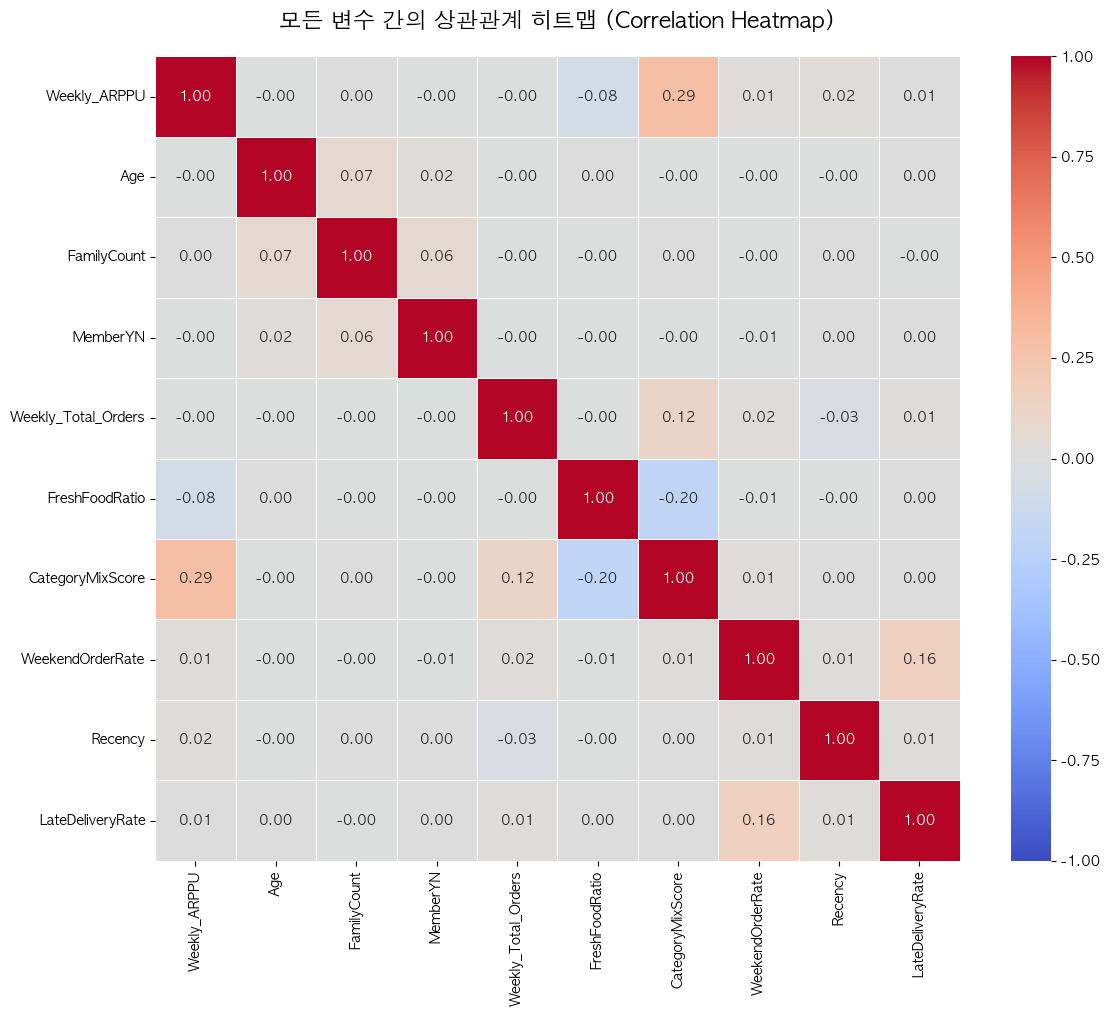


[📊 배송 지연 경험 여부에 따른 주간 객단가(Weekly_ARPPU) 비교]
1. 지연 경험 O 그룹 (평균 객단가): 77,601원 (n=10952)
2. 지연 경험 X 그룹 (평균 객단가): 76,838원 (n=146891)

[🔍 T-검정 결과]
T-statistic: 2.2802
P-value: 0.0226
💡 결론: 배송 지연을 겪은 고객들의 객단가가 통계적으로 유의미하게 더 **높습니다**.
   (해석: 한 번에 많이/무겁게 주문한 VIP 장바구니일수록 배송이 지연될 확률이 높다는 가설 입증!)


/var/folders/cg/m63vxzr11690z4xpkx8d511r0000gn/T/ipykernel_45881/240375558.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


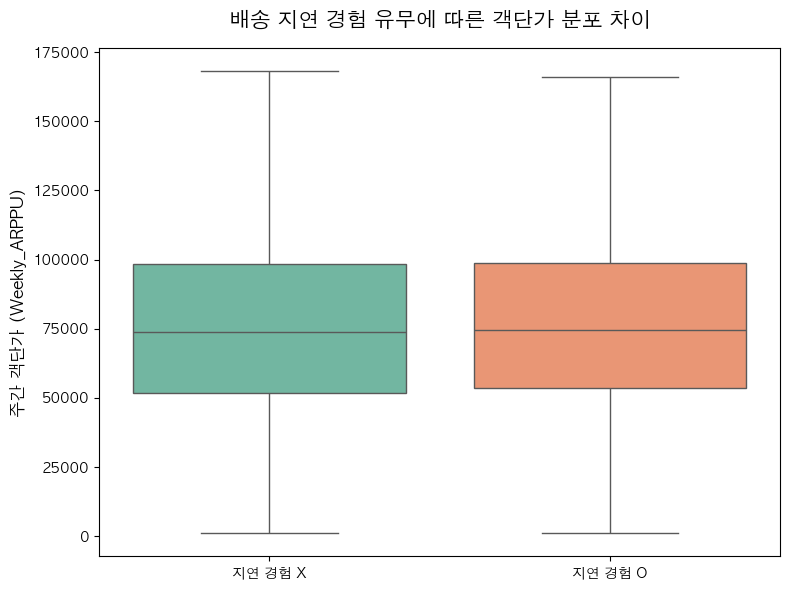

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 맥북(Mac) 환경용 한글 폰트 및 마이너스 깨짐 방지 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# =========================================================
# 1. 상관계수 히트맵 시각화 (Correlation Heatmap)
# =========================================================
# idUser, YearWeek 등 식별자는 제외하고 수치형 변수들만 선택
corr_cols = [
    'Weekly_ARPPU', 'Age', 'FamilyCount', 'MemberYN',
    'Weekly_Total_Orders','FreshFoodRatio', 
    'CategoryMixScore', 
    'WeekendOrderRate', 'Recency', 'LateDeliveryRate'
]

# 상관계수 계산 (Pearson)
corr_matrix = final_dataset[corr_cols].corr()

plt.figure(figsize=(12, 10))
# 히트맵 그리기 (색상이 진할수록 상관관계가 높음)
sns.heatmap(
    corr_matrix, 
    annot=True,          # 칸 안에 숫자 표시
    fmt='.2f',           # 소수점 둘째 자리까지
    cmap='coolwarm',     # 붉은색(양의 상관), 푸른색(음의 상관)
    vmin=-1, vmax=1, 
    center=0,
    square=True,
    linewidths=.5
)

plt.title('모든 변수 간의 상관관계 히트맵 (Correlation Heatmap)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# =========================================================
# 2. 지연 여부에 따른 객단가 T-검정 (T-test)
# =========================================================
# LateDeliveryRate가 0보다 크면 '지연 경험 있음', 0이면 '지연 경험 없음'으로 그룹 분리
delayed_group = final_dataset[final_dataset['LateDeliveryRate'] > 0]['Weekly_ARPPU']
on_time_group = final_dataset[final_dataset['LateDeliveryRate'] == 0]['Weekly_ARPPU']

print("\n[📊 배송 지연 경험 여부에 따른 주간 객단가(Weekly_ARPPU) 비교]")
print(f"1. 지연 경험 O 그룹 (평균 객단가): {delayed_group.mean():,.0f}원 (n={len(delayed_group)})")
print(f"2. 지연 경험 X 그룹 (평균 객단가): {on_time_group.mean():,.0f}원 (n={len(on_time_group)})")

# T-검정 수행 (두 그룹 간의 평균 차이가 통계적으로 유의미한지 검증)
t_stat, p_value = stats.ttest_ind(delayed_group, on_time_group, equal_var=False)

print(f"\n[🔍 T-검정 결과]")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    if t_stat > 0:
        print("💡 결론: 배송 지연을 겪은 고객들의 객단가가 통계적으로 유의미하게 더 **높습니다**.")
        print("   (해석: 한 번에 많이/무겁게 주문한 VIP 장바구니일수록 배송이 지연될 확률이 높다는 가설 입증!)")
    else:
        print("💡 결론: 배송 지연을 겪은 고객들의 객단가가 통계적으로 유의미하게 더 **낮습니다**.")
else:
    print("💡 결론: 배송 지연 여부와 객단가 사이에는 통계적으로 유의미한 차이가 없습니다.")

# 결과를 직관적으로 보여주는 Boxplot 시각화
plt.figure(figsize=(8, 6))

# 시각화를 위해 임시 데이터프레임 생성
box_data = final_dataset.copy()
box_data['지연_경험_여부'] = np.where(box_data['LateDeliveryRate'] > 0, '지연 경험 O', '지연 경험 X')

sns.boxplot(
    x='지연_경험_여부', 
    y='Weekly_ARPPU', 
    data=box_data, 
    palette='Set2',
    showfliers=False # 시각적 편의를 위해 극단적인 이상치(Outlier)는 화면에서 숨김
)

plt.title('배송 지연 경험 유무에 따른 객단가 분포 차이', fontsize=15, fontweight='bold', pad=15)
plt.ylabel('주간 객단가 (Weekly_ARPPU)', fontsize=12)
plt.xlabel('')
plt.tight_layout()
plt.show()

In [164]:
import pandas as pd
from scipy import stats

# 결과를 담을 빈 리스트 생성
test_results = []

# 타겟 변수 및 식별자(id)를 제외한 설명변수 리스트 만들기
# (이전에 누수 변수로 뺐던 BasketSize, AvgItemPrice가 df에 남아있다면 제외하는 것이 좋습니다)
target = 'Weekly_ARPPU'
features = final_dataset.drop(columns=['idUser', 'YearWeek', target])

print("🔍 각 변수의 특성에 맞는 통계 검정을 자동으로 수행합니다...\n")

for col in features.columns:
    # 1. 고유값이 딱 2개인 경우 -> 두 집단 평균 비교 (T-검정)
    if features[col].nunique() == 2:
        val1, val2 = features[col].dropna().unique()
        group1 = final_dataset[final_dataset[col] == val1][target]
        group2 = final_dataset[final_dataset[col] == val2][target]
        
        stat, p_val = stats.ttest_ind(group1, group2, equal_var=False, nan_policy='omit')
        test_name = "T-검정 (T-test)"
        
    # 2. 고유값이 3개~5개 사이인 경우 -> 다중 집단 평균 비교 (ANOVA 분산분석)
    # 예: CategoryMixScore (1, 2, 3, 4)
    elif 2 < features[col].nunique() <= 5:
        groups = [final_dataset[final_dataset[col] == val][target].dropna() for val in features[col].dropna().unique()]
        
        stat, p_val = stats.f_oneway(*groups)
        test_name = "분산분석 (ANOVA)"
        
    # 3. 고유값이 6개 이상인 연속형 숫자인 경우 -> 두 수치형 변수 간의 연관성 (피어슨 상관분석)
    else:
        # 결측치가 있으면 pearsonr이 에러를 내므로 임시로 dropna 처리
        valid_data = final_dataset[[col, target]].dropna()
        stat, p_val = stats.pearsonr(valid_data[col], valid_data[target])
        test_name = "상관분석 (Pearson)"
        
    # 계산된 결과를 리스트에 저장
    test_results.append({
        'Feature': col,
        'Test_Type': test_name,
        'Statistic': stat, # T값, F값, 또는 상관계수(R)
        'P-value': p_val,
        'Is_Significant': p_val < 0.05
    })

# 보기 좋게 데이터프레임으로 변환
results_df = pd.DataFrame(test_results)

# P-value가 작은 순서(유의미한 순서)로 정렬
results_df = results_df.sort_values(by='P-value', ascending=True).reset_index(drop=True)

# 결과 출력 (P-value는 소수점 4자리까지, 통계량은 4자리까지 표기)
display(results_df.style.format({
    'Statistic': '{:.4f}',
    'P-value': '{:.4f}'
}))

🔍 각 변수의 특성에 맞는 통계 검정을 자동으로 수행합니다...



,Feature,Test_Type,Statistic,P-value,Is_Significant
0,CategoryMixScore,분산분석 (ANOVA),6186.5180,0.0000,True
1,FreshFoodRatio,상관분석 (Pearson),-0.0760,0.0000,True
2,Recency,상관분석 (Pearson),0.0177,0.0000,True
3,WeekendOrderRate,상관분석 (Pearson),0.0142,0.0000,True
4,LateDeliveryRate,상관분석 (Pearson),0.0052,0.0383,True
5,Age,상관분석 (Pearson),-0.0021,0.4101,False
6,MemberYN,T-검정 (T-test),-0.7449,0.4563,False
7,Weekly_Total_Orders,분산분석 (ANOVA),0.7094,0.4920,False
8,FamilyCount,분산분석 (ANOVA),0.5867,0.6236,False


# 데이터 누수 컬럼 제외 

## 선형회귀


[📊 컨닝 페이퍼 제거 후 진짜 모델 성능]
RMSE: 32,868원
R-squared: 0.0882 (정상적인 수치로 회귀함)

[🔍 순수 변수별 회귀계수 및 통계적 유의성]


,Feature,Coefficient,P-value,Is_Significant
0,CategoryMixScore,10077.7742,0.0000,True
1,Weekly_Total_Orders,-1283.1876,0.0000,True
2,WeekendOrderRate,1194.4216,0.0000,True
3,FreshFoodRatio,-658.5231,0.0000,True
4,Recency,586.8922,0.0000,True
5,Age,-130.2132,0.1618,False
6,FamilyCount,116.2983,0.2119,False
7,LateDeliveryRate,-32.5652,0.9340,False
8,MemberYN,13.3790,0.9484,False


/var/folders/cg/m63vxzr11690z4xpkx8d511r0000gn/T/ipykernel_45881/1886632132.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_stats, palette=colors)


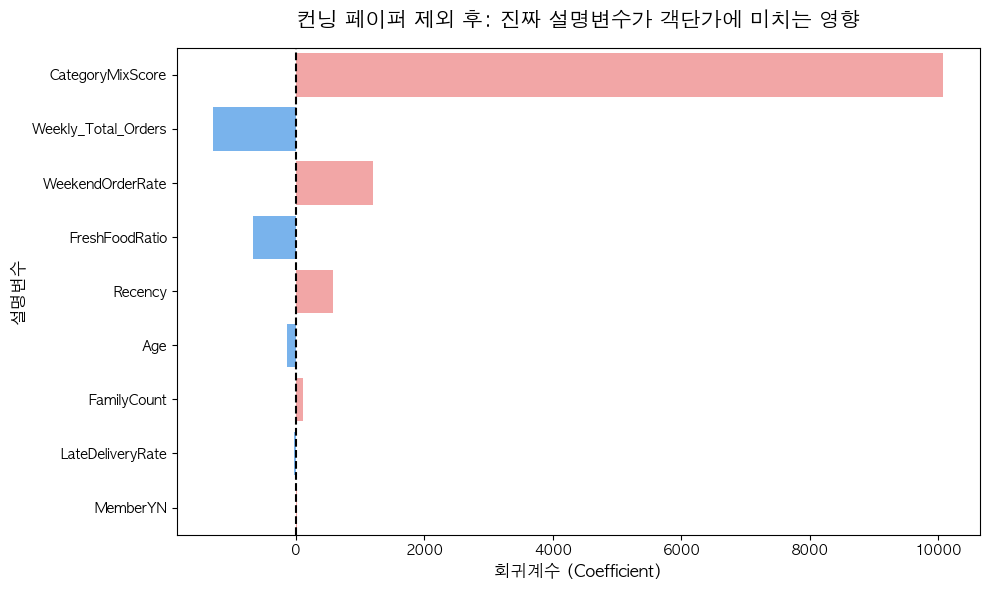

In [165]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. 독립변수(X) 설정 시, 타겟 변수 및 식별자뿐만 아니라 '누수 변수' 2개도 반드시 제외!
leakage_cols = []
X_clean = scaled_dataset.drop(columns=['idUser', 'YearWeek', 'Weekly_ARPPU'] + leakage_cols)
y = scaled_dataset['Weekly_ARPPU']

# 2. Train / Test 데이터 분할 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=42)

# 3. statsmodels OLS 모델 적합 (p-value 확인용)
X_train_sm = sm.add_constant(X_train) # 상수항 추가
model_sm = sm.OLS(y_train, X_train_sm).fit()

# 성능 지표 확인
y_pred_test = model_sm.predict(sm.add_constant(X_test))
r2_clean = r2_score(y_test, y_pred_test)
rmse_clean = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("\n[📊 컨닝 페이퍼 제거 후 진짜 모델 성능]")
print(f"RMSE: {rmse_clean:,.0f}원")
print(f"R-squared: {r2_clean:.4f} (정상적인 수치로 회귀함)")

# 4. 회귀계수와 p-value 추출 및 정리
feature_stats = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model_sm.params[1:].values,
    'P-value': model_sm.pvalues[1:].values
})

feature_stats['Is_Significant'] = feature_stats['P-value'] < 0.05
feature_stats['Abs_Coefficient'] = feature_stats['Coefficient'].abs()
feature_stats = feature_stats.sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)

print("\n[🔍 순수 변수별 회귀계수 및 통계적 유의성]")
display(feature_stats[['Feature', 'Coefficient', 'P-value', 'Is_Significant']].style.format({
    'Coefficient': '{:.4f}',
    'P-value': '{:.4f}'
}))

# 5. 중요 설명변수 시각화
plt.rcParams['font.family'] = 'AppleGothic'  # 맥북 환경 폰트 설정
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))
colors = ['#ff9999' if c > 0 else '#66b3ff' for c in feature_stats['Coefficient']]

sns.barplot(x='Coefficient', y='Feature', data=feature_stats, palette=colors)

plt.title('컨닝 페이퍼 제외 후: 진짜 설명변수가 객단가에 미치는 영향', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('회귀계수 (Coefficient)', fontsize=12)
plt.ylabel('설명변수', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
plt.tight_layout()
plt.show()

## 랜덤포레스트

컨닝 페이퍼를 제외한 순수 데이터로 랜덤포레스트 학습을 시작합니다...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


/opt/anaconda3/envs/beef_ai/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



[📊 순수 데이터 기반 랜덤포레스트 최종 성능]
최적 파라미터: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
RMSE: 28,418원
R-squared: 0.3184


/var/folders/cg/m63vxzr11690z4xpkx8d511r0000gn/T/ipykernel_45881/2572929107.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


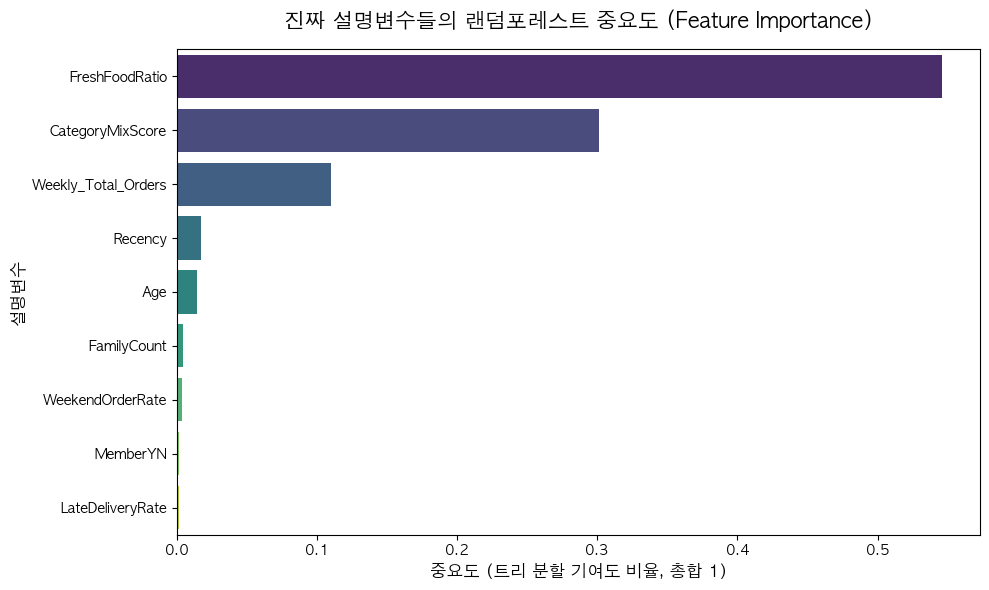

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# 앞선 단계에서 누수 변수가 제거된 데이터(X_clean, y)를 기준으로 
# X_train, X_test, y_train, y_test가 이미 분할되어 있다고 가정합니다.

# ---------------------------------------------------------
# 1. 모델 선언 및 탐색 파라미터 설정
# ---------------------------------------------------------
rf_clean_model = RandomForestRegressor(random_state=42)

# 연산 폭발을 막기 위해 핵심적인 파라미터만 좁혀서 설정
param_grid_clean = {
    'n_estimators': [50, 100],        # 트리 개수
    'max_depth': [5, 10, None],       # 트리 깊이
    'min_samples_split': [2, 5]       # 노드 분할 최소 샘플 수
}

# ---------------------------------------------------------
# 2. GridSearchCV 설정 및 학습 (교차검증 3회, 모든 코어 사용)
# ---------------------------------------------------------
grid_search_clean = GridSearchCV(
    estimator=rf_clean_model,
    param_grid=param_grid_clean,
    cv=3,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    verbose=1 # 진행 상황을 간단히 출력
)

print("컨닝 페이퍼를 제외한 순수 데이터로 랜덤포레스트 학습을 시작합니다...")
grid_search_clean.fit(X_train, y_train)

# ---------------------------------------------------------
# 3. 최적 모델 추출 및 테스트 데이터 성능 평가
# ---------------------------------------------------------
best_rf_clean = grid_search_clean.best_estimator_
y_pred_rf_clean = best_rf_clean.predict(X_test)

rmse_rf_clean = np.sqrt(mean_squared_error(y_test, y_pred_rf_clean))
r2_rf_clean = r2_score(y_test, y_pred_rf_clean)

print("\n[📊 순수 데이터 기반 랜덤포레스트 최종 성능]")
print(f"최적 파라미터: {grid_search_clean.best_params_}")
print(f"RMSE: {rmse_rf_clean:,.0f}원")
print(f"R-squared: {r2_rf_clean:.4f}")

# ---------------------------------------------------------
# 4. 진짜 변수 중요도 (Feature Importance) 시각화
# ---------------------------------------------------------
rf_importances = best_rf_clean.feature_importances_

rf_clean_stats = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_importances
})

# 중요도가 큰 순서대로 정렬
rf_clean_stats = rf_clean_stats.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 맥북(Mac) 환경용 한글 폰트 및 마이너스 깨짐 방지 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))

# seaborn 바 차트 생성
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=rf_clean_stats, 
    palette='viridis'
)

# 그래프 꾸미기
plt.title('진짜 설명변수들의 랜덤포레스트 중요도 (Feature Importance)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('중요도 (트리 분할 기여도 비율, 총합 1)', fontsize=12)
plt.ylabel('설명변수', fontsize=12)

# 출력
plt.tight_layout()
plt.show()

# 그래디언트부스팅

그래디언트 부스팅 학습을 시작합니다. 이전 트리의 오차를 보완하며 순차적으로 학습합니다...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

[📊 그래디언트 부스팅 최종 성능]
최적 파라미터: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
RMSE: 28,351원
R-squared: 0.3216


/var/folders/cg/m63vxzr11690z4xpkx8d511r0000gn/T/ipykernel_45881/390539290.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


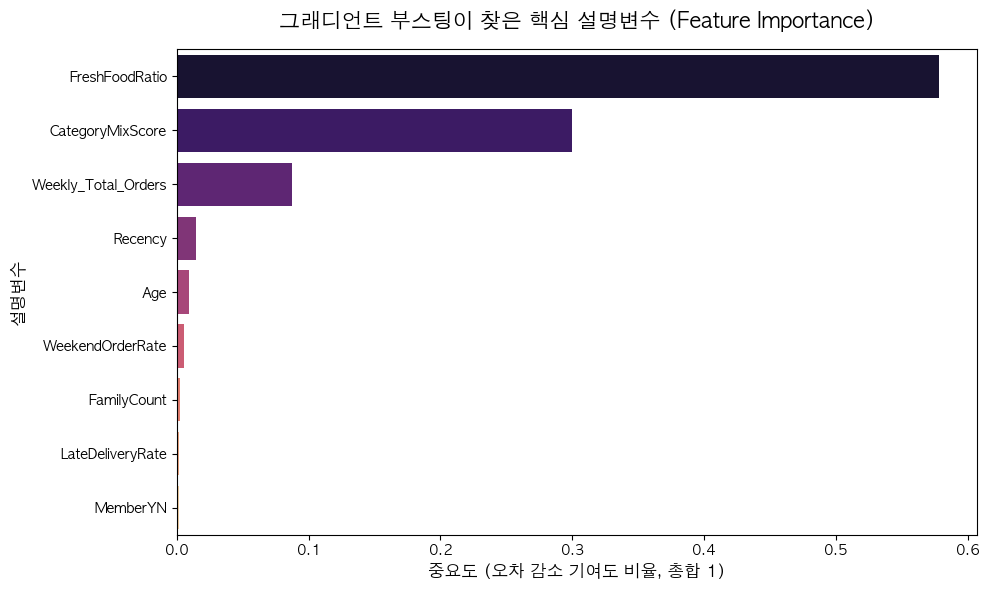

In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# ---------------------------------------------------------
# 1. 모델 선언 및 탐색 파라미터 설정
# ---------------------------------------------------------
gb_model = GradientBoostingRegressor(random_state=42)

# 부스팅 모델의 핵심 파라미터 조합 (학습률과 트리 개수의 밸런스가 중요함)
param_grid_gb = {
    'n_estimators': [100, 200],       # 트리의 개수
    'learning_rate': [0.05, 0.1],     # 오차를 보완해 나가는 보폭 (작을수록 정교하지만 오래 걸림)
    'max_depth': [3, 5]               # 트리의 깊이 (보통 랜덤포레스트보다 얕게 설정함)
}

# ---------------------------------------------------------
# 2. GridSearchCV 설정 및 학습
# ---------------------------------------------------------
grid_search_gb = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid_gb,
    cv=3,
    n_jobs=-1, # 맥북의 모든 코어를 동원해 병렬 연산 속도 극대화
    scoring='neg_mean_squared_error',
    verbose=1
)

print("그래디언트 부스팅 학습을 시작합니다. 이전 트리의 오차를 보완하며 순차적으로 학습합니다...")
grid_search_gb.fit(X_train, y_train)

# ---------------------------------------------------------
# 3. 최적 모델 추출 및 테스트 데이터 성능 평가
# ---------------------------------------------------------
best_gb = grid_search_gb.best_estimator_
y_pred_gb = best_gb.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("\n[📊 그래디언트 부스팅 최종 성능]")
print(f"최적 파라미터: {grid_search_gb.best_params_}")
print(f"RMSE: {rmse_gb:,.0f}원")
print(f"R-squared: {r2_gb:.4f}")

# ---------------------------------------------------------
# 4. 부스팅 모델의 변수 중요도 (Feature Importance) 시각화
# ---------------------------------------------------------
gb_importances = best_gb.feature_importances_

gb_stats = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_importances
})

# 중요도가 큰 순서대로 정렬
gb_stats = gb_stats.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 맥북 환경용 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))

# seaborn 바 차트 생성 (색상 테마 변경)
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=gb_stats, 
    palette='magma'
)

# 그래프 꾸미기
plt.title('그래디언트 부스팅이 찾은 핵심 설명변수 (Feature Importance)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('중요도 (오차 감소 기여도 비율, 총합 1)', fontsize=12)
plt.ylabel('설명변수', fontsize=12)

# 출력
plt.tight_layout()
plt.show()

# XGBoost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# ---------------------------------------------------------
# 1. 모델 선언 및 탐색 파라미터 설정
# ---------------------------------------------------------
xgb_model = XGBRegressor(random_state=42)

param_grid_xgb = {
    'n_estimators': [100, 200],       # 트리 개수
    'learning_rate': [0.05, 0.1],     # 학습률
    'max_depth': [3, 5]               # 트리 깊이
}

# ---------------------------------------------------------
# 2. GridSearchCV 설정 및 학습
# ---------------------------------------------------------
grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=3,
    n_jobs=-1,
    scoring='neg_mean_squared_error',
    verbose=1
)

print("XGBoost 학습을 시작합니다...")
grid_search_xgb.fit(X_train, y_train)

# ---------------------------------------------------------
# 3. 최적 모델 추출 및 테스트 데이터 성능 평가
# ---------------------------------------------------------
best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\n[📊 XGBoost 최종 성능]")
print(f"최적 파라미터: {grid_search_xgb.best_params_}")
print(f"RMSE: {rmse_xgb:,.0f}원")
print(f"R-squared: {r2_xgb:.4f}")

# ---------------------------------------------------------
# 4. 변수 중요도 (Feature Importance) 시각화
# ---------------------------------------------------------
xgb_importances = best_xgb.feature_importances_

xgb_stats = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_importances
})

xgb_stats = xgb_stats.sort_values(by='Importance', ascending=False).reset_index(drop=True)

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=xgb_stats,
    palette='crest'
)

plt.title('XGBoost가 찾은 핵심 설명변수 (Feature Importance)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('중요도 (오차 감소 기여도 비율, 총합 1)', fontsize=12)
plt.ylabel('설명변수', fontsize=12)

plt.tight_layout()
plt.show()

# 모델성능비교

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 4개 모델의 성능 지표 데이터를 데이터프레임으로 묶기
performance_data = {
    'Model': ['선형 회귀\n(Linear Regression)', '랜덤포레스트\n(Random Forest)', '그래디언트 부스팅\n(Gradient Boosting)', 'XGBoost'],
    'RMSE': [rmse_clean, rmse_rf_clean, rmse_gb, rmse_xgb],
    'R_squared': [r2_clean, r2_rf_clean, r2_gb, r2_xgb]
}

perf_df = pd.DataFrame(performance_data)

# 맥북(Mac) 환경용 한글 폰트 및 마이너스 깨짐 방지 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 그래프 그리기 (1행 2열의 서브플롯)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- 첫 번째 그래프: RMSE (오차는 낮을수록 우수함) ---
sns.barplot(x='RMSE', y='Model', data=perf_df, palette='Blues_r', ax=axes[0])
axes[0].set_title('모델별 오차 (RMSE) 비교 - 낮을수록 우수', fontsize=15, fontweight='bold', pad=15)
axes[0].set_xlabel('평균 오차 (원)', fontsize=12)
axes[0].set_ylabel('')

# 막대 끝에 수치 텍스트 달아주기
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_width():,.0f}원", 
                     (p.get_width(), p.get_y() + p.get_height() / 2.), 
                     ha='left', va='center', 
                     xytext=(5, 0), textcoords='offset points', fontsize=12)

# --- 두 번째 그래프: R-squared (설명력은 높을수록 우수함) ---
sns.barplot(x='R_squared', y='Model', data=perf_df, palette='Reds', ax=axes[1])
axes[1].set_title('모델별 설명력 (R-squared) 비교 - 높을수록 우수', fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel('R-squared (0 ~ 1)', fontsize=12)
axes[1].set_ylabel('')

# 막대 끝에 수치 텍스트 달아주기
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_width():.4f}", 
                     (p.get_width(), p.get_y() + p.get_height() / 2.), 
                     ha='left', va='center', 
                     xytext=(5, 0), textcoords='offset points', fontsize=12)

# 레이아웃 간격 조절 후 출력
plt.tight_layout()
plt.show()